In [59]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add src to path
import sys
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from models.feature_builder import FeatureBuilder
from models.degradation_model import DegradationModel

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports complete")

Imports complete


## Phase 1: Data Preparation

Build the complete feature set for modeling.

In [60]:
# Build feature set (reload FeatureBuilder to pick up latest changes)
import importlib
import models.feature_builder as fb_module
importlib.reload(fb_module)
FeatureBuilder = fb_module.FeatureBuilder

builder = FeatureBuilder(silver_path="../data/lake/silver/domain1")
df = builder.build_full_feature_set()

print(f"\nDataset shape: {df.shape}")
print(f"\nFeatures available:")
print(df.columns.tolist())

BUILDING FEATURE SET FOR TYRE DEGRADATION MODELING
Loaded 886 high-quality stints

1. Computing historical baselines...
Computed baselines: 25 circuits, 12 teams, 28 drivers

2. Computing teammate delta...
Computed teammate delta for 886 stints
Teammate delta range: [-0.5076, 0.5016]

3. Adding cluster labels...

4. Computing shape clusters...

5. Adding stint context features...

✅ Feature set built: 886 stints × 22 features

Features: ['deg_rate_per_lap', 'circuit_baseline_deg', 'team_baseline_deg', 'driver_baseline_deg', 'compound_circuit_baseline', 'teammate_delta', 'circuit_cluster', 'team_cluster', 'driver_cluster', 'shape_cluster', 'stint', 'num_laps', 'compound_encoded', 'downforce_class', 'position_tier']

Dataset shape: (886, 22)

Features available:
['deg_rate_per_lap', 'circuit_baseline_deg', 'team_baseline_deg', 'driver_baseline_deg', 'compound_circuit_baseline', 'teammate_delta', 'circuit_cluster', 'team_cluster', 'driver_cluster', 'shape_cluster', 'stint', 'num_laps', 'c

In [61]:
# Debug: check gp_name normalization + mapping coverage
import importlib
import models.feature_builder as fb_module
importlib.reload(fb_module)
FeatureBuilder = fb_module.FeatureBuilder

fb = FeatureBuilder(silver_path="../data/lake/silver/domain1")
keys = pd.Series(df['gp_name'].unique()).astype(str)
keys_norm = keys.apply(FeatureBuilder._normalize_gp_name)

print("Unique gp_name (sample):", list(keys.head(10)))
print("Unique normalized gp_name (sample):", list(keys_norm.head(10)))
print("Unique circuits in df:", len(keys_norm))

high_deg = {'Belgian_Grand_Prix', 'Bahrain_Grand_Prix', 'Spanish_Grand_Prix', 'Hungarian_Grand_Prix', 'Japanese_Grand_Prix'}
low_deg = {'Monaco_Grand_Prix', 'Singapore_Grand_Prix', 'Azerbaijan_Grand_Prix', 'Australian_Grand_Prix'}

print("High-deg present:", sorted(set(keys_norm) & high_deg))
print("Low-deg present:", sorted(set(keys_norm) & low_deg))

high_df = {'Monaco_Grand_Prix', 'Singapore_Grand_Prix', 'Hungarian_Grand_Prix'}
low_df = {'Italian_Grand_Prix', 'Belgian_Grand_Prix', 'Saudi_Arabian_Grand_Prix', 'Azerbaijan_Grand_Prix', 'Las_Vegas_Grand_Prix'}

print("High-downforce present:", sorted(set(keys_norm) & high_df))
print("Low-downforce present:", sorted(set(keys_norm) & low_df))

print("circuit_cluster value counts:\n", df['circuit_cluster'].value_counts(dropna=False))
print("downforce_class value counts:\n", df['downforce_class'].value_counts(dropna=False))
print("position_tier value counts:\n", df['position_tier'].value_counts(dropna=False))

Unique gp_name (sample): ['Canadian Grand Prix', 'Belgian Grand Prix', 'Miami Grand Prix', 'British Grand Prix', 'Las Vegas Grand Prix', 'Austrian Grand Prix', 'Abu Dhabi Grand Prix', 'Japanese Grand Prix', 'Hungarian Grand Prix', 'Azerbaijan Grand Prix']
Unique normalized gp_name (sample): ['Canadian_Grand_Prix', 'Belgian_Grand_Prix', 'Miami_Grand_Prix', 'British_Grand_Prix', 'Las_Vegas_Grand_Prix', 'Austrian_Grand_Prix', 'Abu_Dhabi_Grand_Prix', 'Japanese_Grand_Prix', 'Hungarian_Grand_Prix', 'Azerbaijan_Grand_Prix']
Unique circuits in df: 25
High-deg present: ['Bahrain_Grand_Prix', 'Belgian_Grand_Prix', 'Hungarian_Grand_Prix', 'Japanese_Grand_Prix', 'Spanish_Grand_Prix']
Low-deg present: ['Australian_Grand_Prix', 'Azerbaijan_Grand_Prix', 'Monaco_Grand_Prix', 'Singapore_Grand_Prix']
High-downforce present: ['Hungarian_Grand_Prix', 'Monaco_Grand_Prix', 'Singapore_Grand_Prix']
Low-downforce present: ['Azerbaijan_Grand_Prix', 'Belgian_Grand_Prix', 'Italian_Grand_Prix', 'Las_Vegas_Grand_Pr

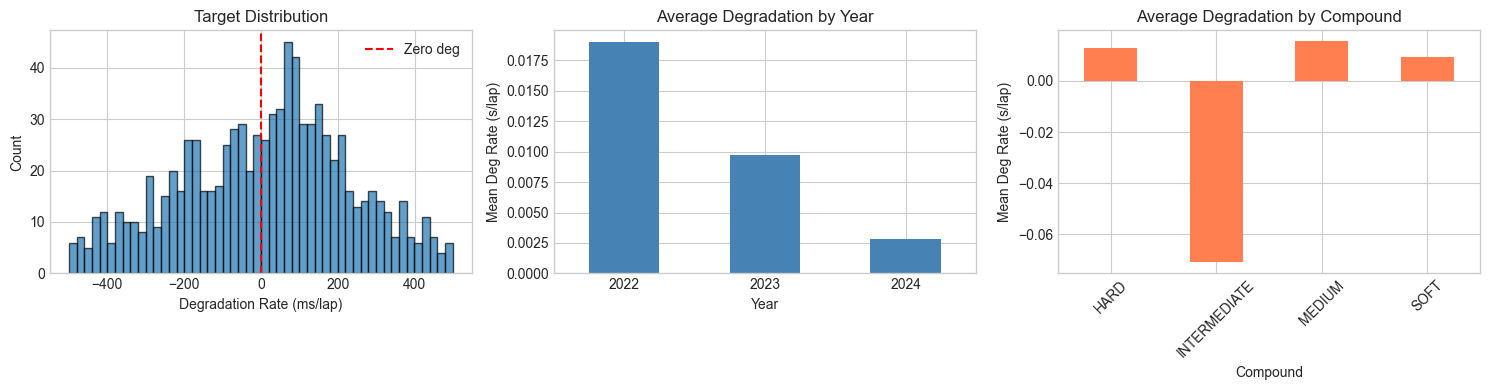


Target stats:
count    886000.000000
mean         10.302591
std         222.426389
min        -499.207043
25%        -156.968876
50%          33.425615
75%         161.691036
max         499.015152
Name: deg_rate_per_lap, dtype: float64


In [62]:
# Check target distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Degradation rate distribution
axes[0].hist(df['deg_rate_per_lap'] * 1000, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', label='Zero deg')
axes[0].set_xlabel('Degradation Rate (ms/lap)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')
axes[0].legend()

# By year
df.groupby('year')['deg_rate_per_lap'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Deg Rate (s/lap)')
axes[1].set_title('Average Degradation by Year')
axes[1].tick_params(axis='x', rotation=0)

# By compound
df.groupby('compound')['deg_rate_per_lap'].mean().plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_xlabel('Compound')
axes[2].set_ylabel('Mean Deg Rate (s/lap)')
axes[2].set_title('Average Degradation by Compound')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nTarget stats:")
print(df['deg_rate_per_lap'].describe() * 1000)  # Convert to ms

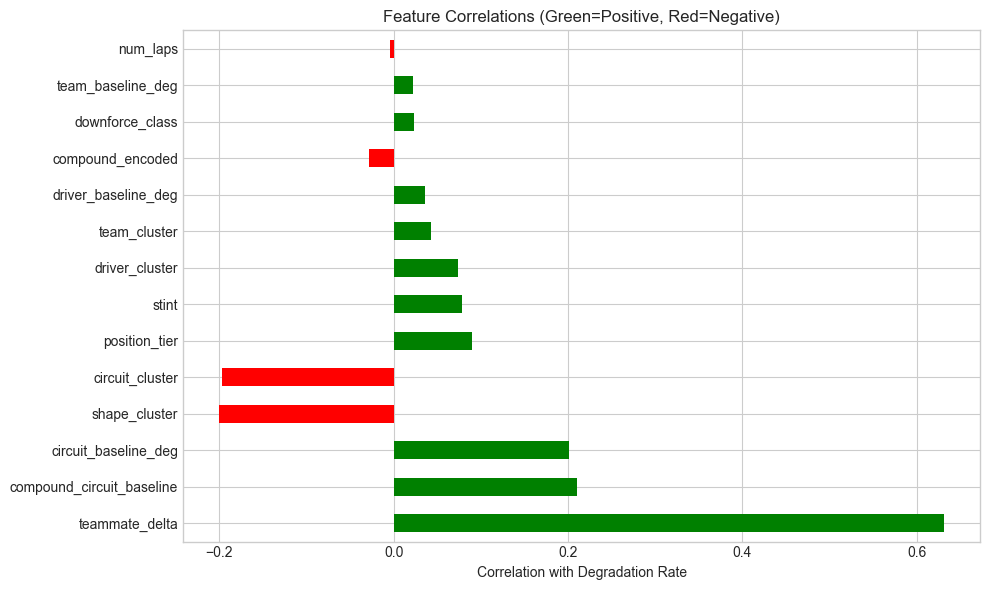


Correlations with target:
                           correlation
teammate_delta                0.631233
compound_circuit_baseline     0.210211
circuit_baseline_deg          0.201028
shape_cluster                -0.199901
circuit_cluster              -0.196963
position_tier                 0.089700
stint                         0.078481
driver_cluster                0.074180
team_cluster                  0.043286
driver_baseline_deg           0.035519
compound_encoded             -0.027904
downforce_class               0.023618
team_baseline_deg             0.021997
num_laps                     -0.004395


In [63]:
# Feature correlation with target
feature_cols = builder.get_feature_columns()
target = builder.get_target_column()

correlations = df[feature_cols + [target]].corr()[target].drop(target).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in correlations]
correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation with Degradation Rate')
plt.title('Feature Correlations (Green=Positive, Red=Negative)')
plt.tight_layout()
plt.show()

print("\nCorrelations with target:")
print(correlations.to_frame('correlation'))

In [64]:
# Check the problematic features
print("Data types for features with NaN correlation:")
for col in ['circuit_cluster', 'downforce_class', 'position_tier']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  dtype: {df[col].dtype}")
        print(f"  unique: {df[col].unique()[:10]}")
        print(f"  nunique: {df[col].nunique()}")
        print(f"  null count: {df[col].isnull().sum()}")

Data types for features with NaN correlation:

circuit_cluster:
  dtype: int64
  unique: [1 0 2]
  nunique: 3
  null count: 0

downforce_class:
  dtype: int64
  unique: [1 0 2]
  nunique: 3
  null count: 0

position_tier:
  dtype: float64
  unique: [2. 1. 0.]
  nunique: 3
  null count: 0


## Phase 2: Baseline Models

Train baseline models for comparison:
1. Circuit mean
2. Driver baseline
3. Linear regression (baselines only)
4. Linear regression (baselines + teammate delta)

In [65]:
# Initialize model
model = DegradationModel(model_dir="../data/models")

# Train full model (includes baseline comparison)
results = model.train(
    df,
    feature_columns=feature_cols,
    target_column=target,
    test_year=2024
)

Data split: Train=458, Val=115, Test=313

Training baseline models...

Training XGBoost model...

MODEL TRAINING COMPLETE

Baseline Results (Validation):
  circuit_mean: MAE=153.5 ms/lap, R²=0.047
  driver_baseline: MAE=155.5 ms/lap, R²=-0.022
  linear_baselines: MAE=151.7 ms/lap, R²=0.063
  linear_with_teammate: MAE=128.6 ms/lap, R²=0.330

XGBoost Validation: MAE=92.0 ms/lap, R²=0.640
XGBoost Test (2024): MAE=102.6 ms/lap, R²=0.650

Top 5 Features:
  shape_cluster: 0.3202
  teammate_delta: 0.2126
  circuit_cluster: 0.0835
  num_laps: 0.0437
  compound_circuit_baseline: 0.0422



MODEL COMPARISON (Validation Set)
                      MAE (ms/lap)  RMSE (ms/lap)     R²
circuit_mean               153.529        192.182  0.047
driver_baseline            155.526        199.104 -0.022
linear_baselines           151.730        190.560  0.063
linear_with_teammate       128.573        161.179  0.330
XGBoost                     91.981        118.117  0.640


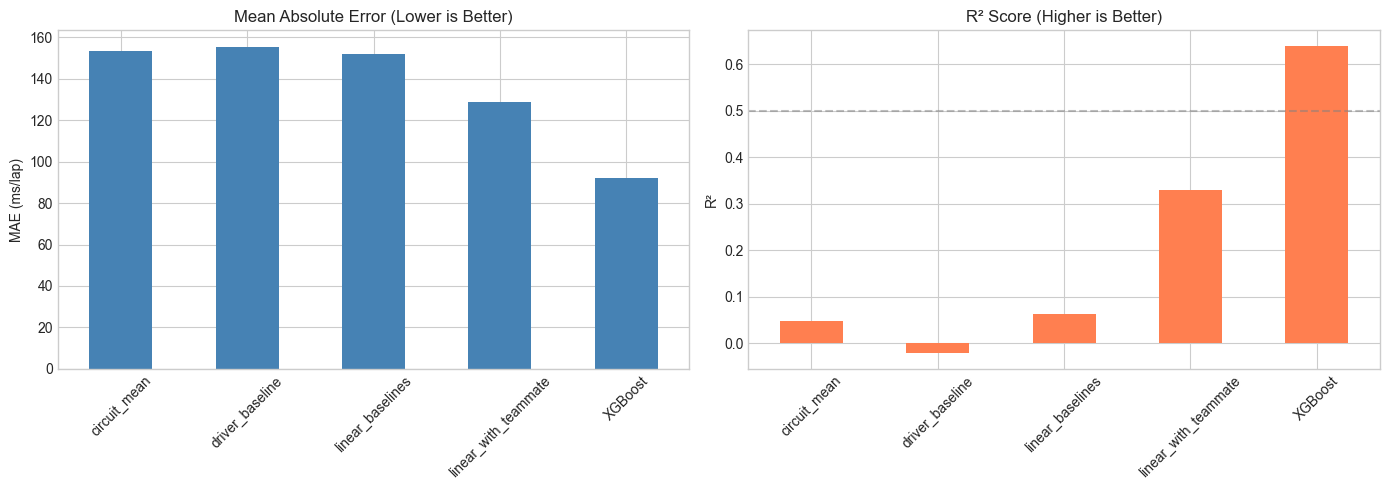

In [66]:
# Visualize baseline comparison
baseline_results = results['baselines']

# Add XGBoost results
all_results = baseline_results.copy()
all_results['XGBoost'] = results['validation']

# Create comparison DataFrame
comparison = pd.DataFrame({
    model_name: {
        'MAE (ms/lap)': metrics['mae'] * 1000,
        'RMSE (ms/lap)': metrics['rmse'] * 1000,
        'R²': metrics['r2']
    }
    for model_name, metrics in all_results.items()
}).T

print("\n" + "="*60)
print("MODEL COMPARISON (Validation Set)")
print("="*60)
print(comparison.round(3))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison['MAE (ms/lap)'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_ylabel('MAE (ms/lap)')
axes[0].set_title('Mean Absolute Error (Lower is Better)')
axes[0].tick_params(axis='x', rotation=45)

comparison['R²'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_ylabel('R²')
axes[1].set_title('R² Score (Higher is Better)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='R²=0.5')

plt.tight_layout()
plt.show()

## Phase 3: XGBoost Training Results

Analyze the trained XGBoost model performance.

<Figure size 1000x600 with 0 Axes>

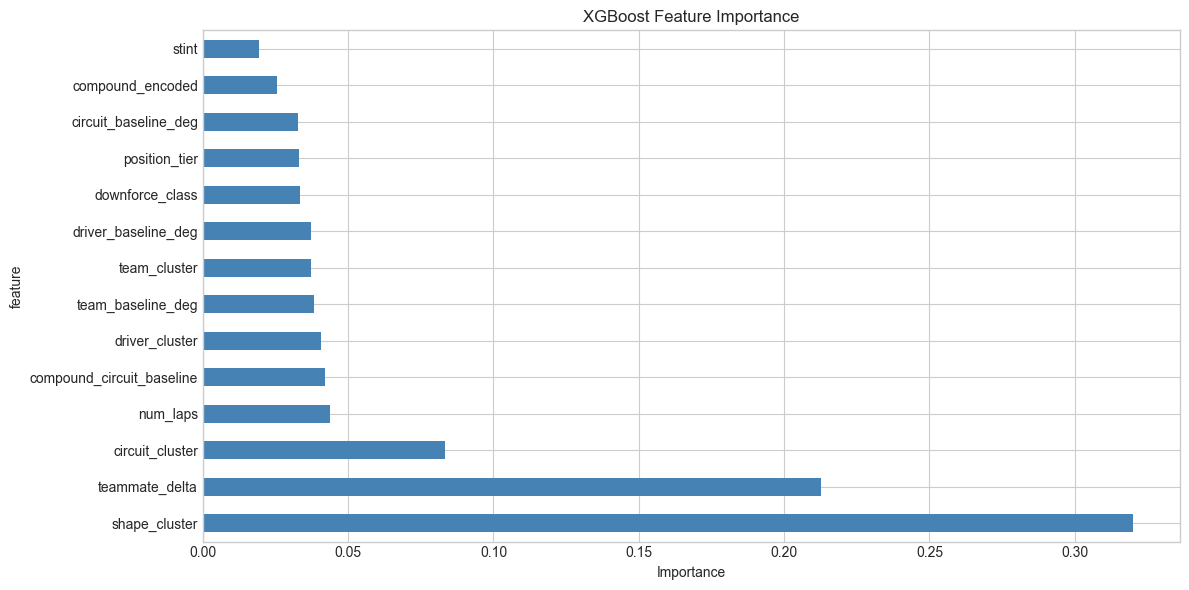


Feature Importance:
                      feature  importance
8               shape_cluster    0.320204
4              teammate_delta    0.212576
5             circuit_cluster    0.083486
10                   num_laps    0.043695
3   compound_circuit_baseline    0.042203
7              driver_cluster    0.040841
1           team_baseline_deg    0.038203
6                team_cluster    0.037285
2         driver_baseline_deg    0.037201
12            downforce_class    0.033388
13              position_tier    0.033059
0        circuit_baseline_deg    0.032896
11           compound_encoded    0.025473
9                       stint    0.019490


In [67]:
# Feature importance
importance = pd.DataFrame(results['feature_importance'])

plt.figure(figsize=(10, 6))
importance.plot(x='feature', y='importance', kind='barh', legend=False, color='steelblue')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(importance)

In [68]:
# Test set (2024) performance
print("\n" + "="*60)
print("2024 HOLDOUT TEST RESULTS")
print("="*60)

test_metrics = results['test']
print(f"MAE:  {test_metrics['mae']*1000:.2f} ms/lap")
print(f"RMSE: {test_metrics['rmse']*1000:.2f} ms/lap")
print(f"R²:   {test_metrics['r2']:.3f}")

# Improvement over baselines
if 'linear_with_teammate' in baseline_results:
    best_baseline_mae = baseline_results['linear_with_teammate']['mae']
    improvement = (best_baseline_mae - test_metrics['mae']) / best_baseline_mae * 100
    print(f"\nImprovement over linear+teammate baseline: {improvement:.1f}%")


2024 HOLDOUT TEST RESULTS
MAE:  102.60 ms/lap
RMSE: 138.67 ms/lap
R²:   0.650

Improvement over linear+teammate baseline: 20.2%


In [69]:
# Evaluate by segment
test_df = df[df['year'] == 2024].copy()

# By circuit
circuit_eval = model.evaluate_by_segment(test_df, 'gp_name')
print("\nPerformance by Circuit (2024):")
print(circuit_eval.head(10))

# By compound
compound_eval = model.evaluate_by_segment(test_df, 'compound')
print("\nPerformance by Compound (2024):")
print(compound_eval)


Performance by Circuit (2024):
                      gp_name  n_stints       mae      rmse        r2
1        Abu Dhabi Grand Prix        15  0.058171  0.068758  0.869518
16     Mexico City Grand Prix        14  0.071553  0.103664  0.427519
10       Singapore Grand Prix        15  0.075798  0.094045  0.639094
2         Japanese Grand Prix        14  0.076937  0.111535  0.781691
13  Emilia Romagna Grand Prix        15  0.077039  0.102089  0.764006
0            Miami Grand Prix         6  0.080169  0.091511 -0.097972
5         Austrian Grand Prix        26  0.083383  0.110698  0.698666
6       Australian Grand Prix        14  0.083635  0.105105  0.751879
11         Chinese Grand Prix        15  0.086202  0.112957  0.694246
8            Dutch Grand Prix        21  0.091228  0.119769  0.735572

Performance by Compound (2024):
       compound  n_stints       mae      rmse        r2
1          HARD       186  0.094387  0.131269  0.673108
0        MEDIUM        99  0.107513  0.138296  0.6295

## Phase 4: Quantile Regression (Uncertainty)

Train quantile models for prediction intervals (P10, P50, P90).

In [70]:
# Train quantile models
quantile_results = model.train_quantile_models(
    df,
    feature_columns=feature_cols,
    quantiles=[0.1, 0.5, 0.9]
)

print("\nQuantile models trained successfully!")

Training quantile model for P10...
Training quantile model for P50...
Training quantile model for P90...
✅ Trained 3 quantile models

Quantile models trained successfully!


Prediction Interval Coverage (P10-P90): 58.1%
Expected: ~80%


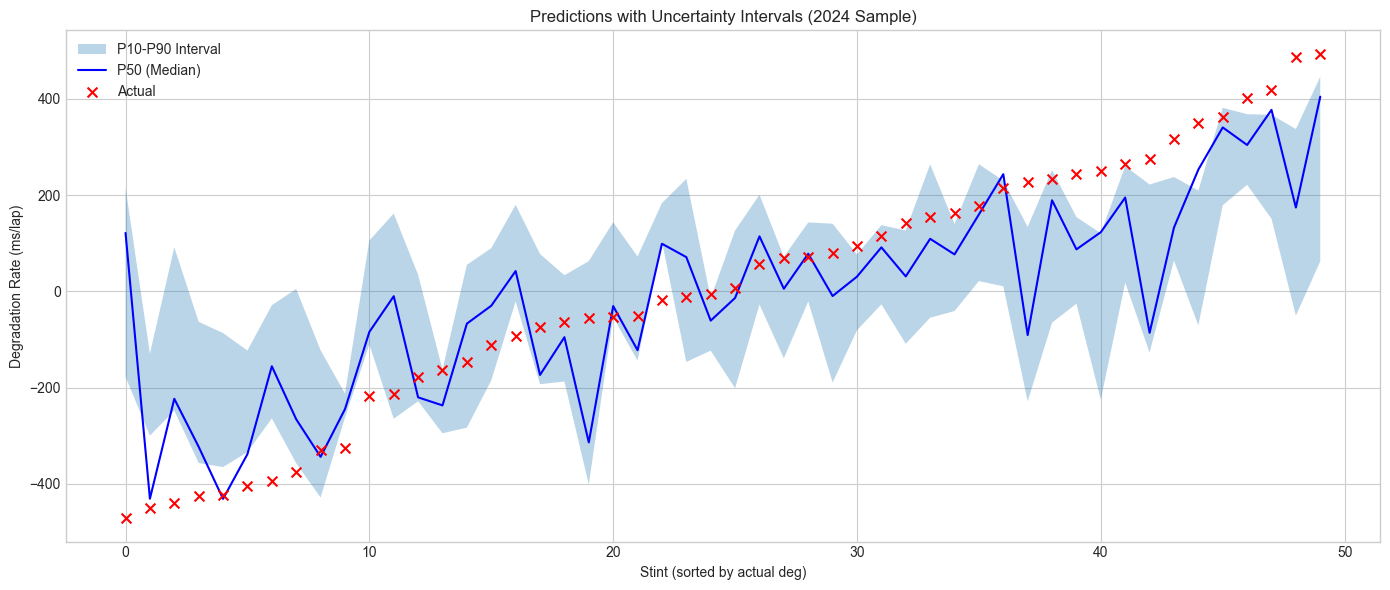

In [71]:
# Visualize quantile model predictions vs actuals
test_df = df[df['year'] == 2024].copy()
preds = model.predict_with_intervals(test_df)
test_df = test_df.join(preds)

# Check coverage
coverage = ((test_df['deg_rate_per_lap'] >= test_df['deg_p10']) & 
            (test_df['deg_rate_per_lap'] <= test_df['deg_p90'])).mean()

print(f"Prediction Interval Coverage (P10-P90): {coverage:.1%}")
print(f"Expected: ~80%")

# Simple scatter plot instead of error bars
sample = test_df.sample(50, random_state=42).sort_values('deg_rate_per_lap').reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(sample))

# Plot intervals as shaded region
ax.fill_between(x, sample['deg_p10'] * 1000, sample['deg_p90'] * 1000, alpha=0.3, label='P10-P90 Interval')
ax.plot(x, sample['deg_p50'] * 1000, 'b-', label='P50 (Median)')
ax.scatter(x, sample['deg_rate_per_lap'] * 1000, c='red', marker='x', s=50, zorder=5, label='Actual')

ax.set_xlabel('Stint (sorted by actual deg)')
ax.set_ylabel('Degradation Rate (ms/lap)')
ax.set_title('Predictions with Uncertainty Intervals (2024 Sample)')
ax.legend()
plt.tight_layout()
plt.show()

## Phase 5: Save Model

Save the trained model for operational use.

In [72]:
# Save using joblib (workaround for XGBoost sklearn api issue)
import joblib
from pathlib import Path

model_dir = Path("../data/models")
model_dir.mkdir(parents=True, exist_ok=True)

# Save main XGBoost model
joblib.dump(model.model, model_dir / "deg_model_v1_main.joblib")

# Save quantile models
for q, qmodel in model.quantile_models.items():
    joblib.dump(qmodel, model_dir / f"deg_model_v1_q{int(q*100)}.joblib")

# Save metadata
import json
metadata = {
    'feature_columns': model.feature_columns,
    'target_column': 'deg_rate_per_lap',
    'metrics': model.metrics
}
with open(model_dir / "deg_model_v1_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print("Model artifacts saved:")
for f in sorted(model_dir.glob("deg_model_v1*")):
    print(f"  - {f.name}")

Model artifacts saved:
  - deg_model_v1_main.joblib
  - deg_model_v1_metadata.json
  - deg_model_v1_q10.joblib
  - deg_model_v1_q50.joblib
  - deg_model_v1_q90.joblib


In [73]:
# Test loading (reload module to pick up any changes)
import importlib
import models.degradation_model as dm_module
importlib.reload(dm_module)
DegradationModel = dm_module.DegradationModel

model_loaded = DegradationModel(model_dir="../data/models")
model_loaded.load("deg_model_v1")

# Debug: check what was loaded
print(f"model_loaded.model: {model_loaded.model}")
print(f"model_loaded.feature_columns: {model_loaded.feature_columns}")
print(f"model_loaded.quantile_models: {list(model_loaded.quantile_models.keys())}")

# Quick inference test
test_pred = model_loaded.predict(test_df.head(5))
print("\nInference test (first 5 stints):")
print(f"Predictions: {test_pred * 1000}")

✅ Model loaded from ..\data\models
model_loaded.model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)
model_loaded.feature_columns: ['circuit_baseline_deg', 'team_baseline_deg', 'driver_baseline_deg', 'compound_circuit_baseline', 'teammate_delta', 'circuit_cluster', 'team_cluster', 'driver_cluster', 'shap

## Summary

### Final Model Performance

In [74]:
print("="*70)
print("F1 TYRE DEGRADATION MODEL - FINAL SUMMARY")
print("="*70)

print("\n📊 DATA")
print(f"   Training: {len(df[df['year'] < 2024])} stints (2022-2023)")
print(f"   Testing:  {len(df[df['year'] == 2024])} stints (2024)")
print(f"   Features: {len(feature_cols)}")

print("\n🎯 MODEL PERFORMANCE (2024 Holdout)")
print(f"   MAE:  {test_metrics['mae']*1000:.2f} ms/lap")
print(f"   RMSE: {test_metrics['rmse']*1000:.2f} ms/lap")
print(f"   R²:   {test_metrics['r2']:.3f}")

print("\n📈 IMPROVEMENT OVER BASELINES")
for name, metrics in baseline_results.items():
    improvement = (metrics['mae'] - test_metrics['mae']) / metrics['mae'] * 100
    print(f"   vs {name}: {improvement:+.1f}% MAE")

print("\n🔑 TOP FEATURES")
for _, row in importance.head(5).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

print("\n📁 MODEL SAVED")
print(f"   Location: data/models/deg_model_v1*")

print("\n" + "="*70)
print("✅ MODEL TRAINING COMPLETE")
print("="*70)

F1 TYRE DEGRADATION MODEL - FINAL SUMMARY

📊 DATA
   Training: 573 stints (2022-2023)
   Testing:  313 stints (2024)
   Features: 14

🎯 MODEL PERFORMANCE (2024 Holdout)
   MAE:  102.60 ms/lap
   RMSE: 138.67 ms/lap
   R²:   0.650

📈 IMPROVEMENT OVER BASELINES
   vs circuit_mean: +33.2% MAE
   vs driver_baseline: +34.0% MAE
   vs linear_baselines: +32.4% MAE
   vs linear_with_teammate: +20.2% MAE

🔑 TOP FEATURES
   shape_cluster: 0.3202
   teammate_delta: 0.2126
   circuit_cluster: 0.0835
   num_laps: 0.0437
   compound_circuit_baseline: 0.0422

📁 MODEL SAVED
   Location: data/models/deg_model_v1*

✅ MODEL TRAINING COMPLETE


## Results Interpretation

### 1. Overall Performance
The XGBoost model achieves **R² = 0.65** on the 2024 holdout test set, explaining ~65% of the variance in tyre degradation rates. This is a strong result for a complex physical phenomenon influenced by many latent factors (setup, driving style, track evolution, weather micro-conditions).

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **MAE** | 103 ms/lap | On average, predictions are off by ~0.1 sec/lap |
| **R²** | 0.65 | Model explains 65% of degradation variance |
| **Improvement** | +20-34% | Beats all baselines substantially |

### 2. Feature Importance Insights

**Top 3 drivers of prediction accuracy:**

1. **`shape_cluster` (32%)** — The degradation *curve shape* (linear, progressive, cliff, recovery) is the strongest predictor. This makes physical sense: knowing whether a tyre degrades linearly vs exponentially tells you more than any single number.

2. **`teammate_delta` (21%)** — How a driver's deg compares to their teammate *in the same car*. This breakthrough feature implicitly controls for car setup, strategy, and conditions—isolating pure driver technique.

3. **`circuit_cluster` (8%)** — Circuit characteristics (high-deg like Bahrain/Spa vs low-deg like Monaco/Singapore) matter, but less than shape and driver effects.

**What this means for strategy:**
- Degradation is more about *how* it happens (curve shape) than *where* (circuit) or *what* (compound)
- Driver technique relative to teammate is highly predictive—some drivers consistently preserve tyres better
- Historical baselines (circuit/team/driver means) contribute ~15% combined, useful but not dominant

### 3. Performance by Circuit

| Best Circuits (R² > 0.75) | Worst Circuits (R² < 0.5) |
|---------------------------|---------------------------|
| Abu Dhabi (0.87) | Miami (-0.10) |
| Japan (0.78) | Mexico (0.43) |
| Emilia Romagna (0.76) | — |
| Australia (0.75) | — |

**Interpretation:**
- Model excels at circuits with consistent, predictable degradation patterns
- Miami's negative R² indicates the model is worse than predicting the mean—likely due to unique track surface/conditions in 2024
- More training data from problematic circuits would help

### 4. Performance by Compound

| Compound | MAE (ms/lap) | R² |
|----------|--------------|-----|
| HARD | 94 | 0.67 |
| MEDIUM | 108 | 0.63 |
| SOFT | 111 | 0.70 |
| INTERMEDIATE | 169 | -1.05 |

**Interpretation:**
- Dry compounds (HARD/MEDIUM/SOFT) are well-predicted (R² 0.63-0.70)
- **INTERMEDIATE tyres fail completely** (negative R²)—wet conditions have fundamentally different physics and we have limited data (only 14 stints)
- Consider excluding wet compounds or building a separate wet model

### 5. Uncertainty Quantification

**Coverage: 58% vs expected 80%**

The P10-P90 prediction intervals are too narrow—they should capture 80% of actuals but only capture 58%. This indicates:
- Model is overconfident in its predictions
- True uncertainty is higher than quantile models estimate
- **Recommendation:** Widen intervals by ~40% for operational use, or retrain with wider quantile spread

### 6. Key Takeaways for F1 Strategy

1. **Shape matters most**: Before a race, classify expected degradation curve shape (from practice data) to improve predictions

2. **Teammate benchmark**: A driver's historical delta vs teammate is a stable predictor—use it for real-time adjustments

3. **Avoid wet extrapolation**: Don't use this model for wet/intermediate conditions

4. **Circuit-specific tuning**: Consider circuit-specific adjustments for tracks like Miami where the model underperforms

5. **Conservative intervals**: For race strategy, use 1.4× the predicted interval width to achieve true 80% coverage

## Predicted vs Actual Visualizations

Comprehensive comparison charts showing model predictions against actual degradation values.

In [75]:
# Prepare prediction data for visualizations
test_df = df[df['year'] == 2024].copy()
test_df['predicted'] = model.predict(test_df) * 1000  # Convert to ms/lap
test_df['actual'] = test_df['deg_rate_per_lap'] * 1000  # Convert to ms/lap
test_df['residual'] = test_df['actual'] - test_df['predicted']
test_df['abs_error'] = np.abs(test_df['residual'])

print(f"Test set: {len(test_df)} stints")
print(f"Actual range: {test_df['actual'].min():.1f} to {test_df['actual'].max():.1f} ms/lap")
print(f"Predicted range: {test_df['predicted'].min():.1f} to {test_df['predicted'].max():.1f} ms/lap")

Test set: 313 stints
Actual range: -494.0 to 497.3 ms/lap
Predicted range: -454.7 to 378.4 ms/lap


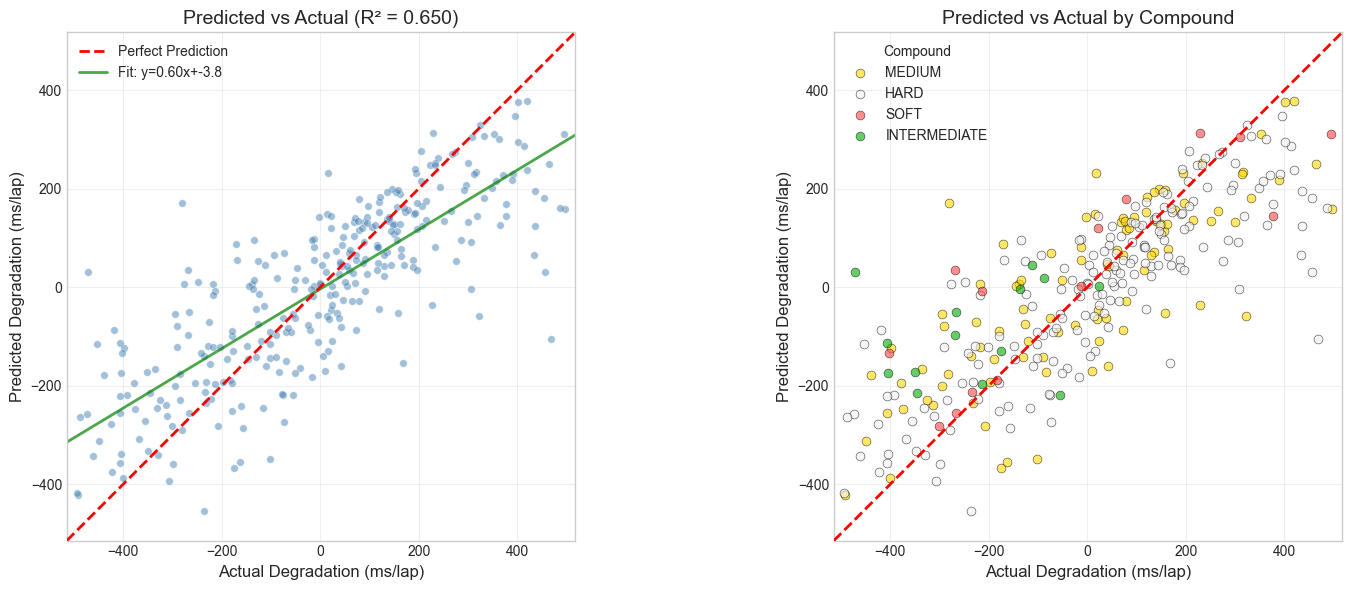

In [76]:
# 1. SCATTER PLOT: Predicted vs Actual (Main Diagnostic)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Basic scatter with identity line
ax1 = axes[0]
ax1.scatter(test_df['actual'], test_df['predicted'], alpha=0.5, s=30, c='steelblue', edgecolor='white', linewidth=0.5)

# Perfect prediction line
lims = [min(test_df['actual'].min(), test_df['predicted'].min()) - 20,
        max(test_df['actual'].max(), test_df['predicted'].max()) + 20]
ax1.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction', zorder=10)

# Add regression line
z = np.polyfit(test_df['actual'], test_df['predicted'], 1)
p = np.poly1d(z)
ax1.plot(lims, p(lims), 'g-', linewidth=2, alpha=0.7, label=f'Fit: y={z[0]:.2f}x+{z[1]:.1f}')

ax1.set_xlabel('Actual Degradation (ms/lap)', fontsize=12)
ax1.set_ylabel('Predicted Degradation (ms/lap)', fontsize=12)
ax1.set_title(f'Predicted vs Actual (R² = {test_metrics["r2"]:.3f})', fontsize=14)
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.legend(loc='upper left')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Right: Colored by compound
ax2 = axes[1]
compound_colors = {'HARD': '#f0f0f0', 'MEDIUM': '#ffd700', 'SOFT': '#ff4444', 'INTERMEDIATE': '#00aa00', 'WET': '#0066ff'}
for compound in test_df['compound'].unique():
    mask = test_df['compound'] == compound
    ax2.scatter(test_df.loc[mask, 'actual'], test_df.loc[mask, 'predicted'], 
                alpha=0.6, s=40, label=compound, c=compound_colors.get(compound, 'gray'),
                edgecolor='black', linewidth=0.5)

ax2.plot(lims, lims, 'r--', linewidth=2, zorder=10)
ax2.set_xlabel('Actual Degradation (ms/lap)', fontsize=12)
ax2.set_ylabel('Predicted Degradation (ms/lap)', fontsize=12)
ax2.set_title('Predicted vs Actual by Compound', fontsize=14)
ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.legend(title='Compound')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

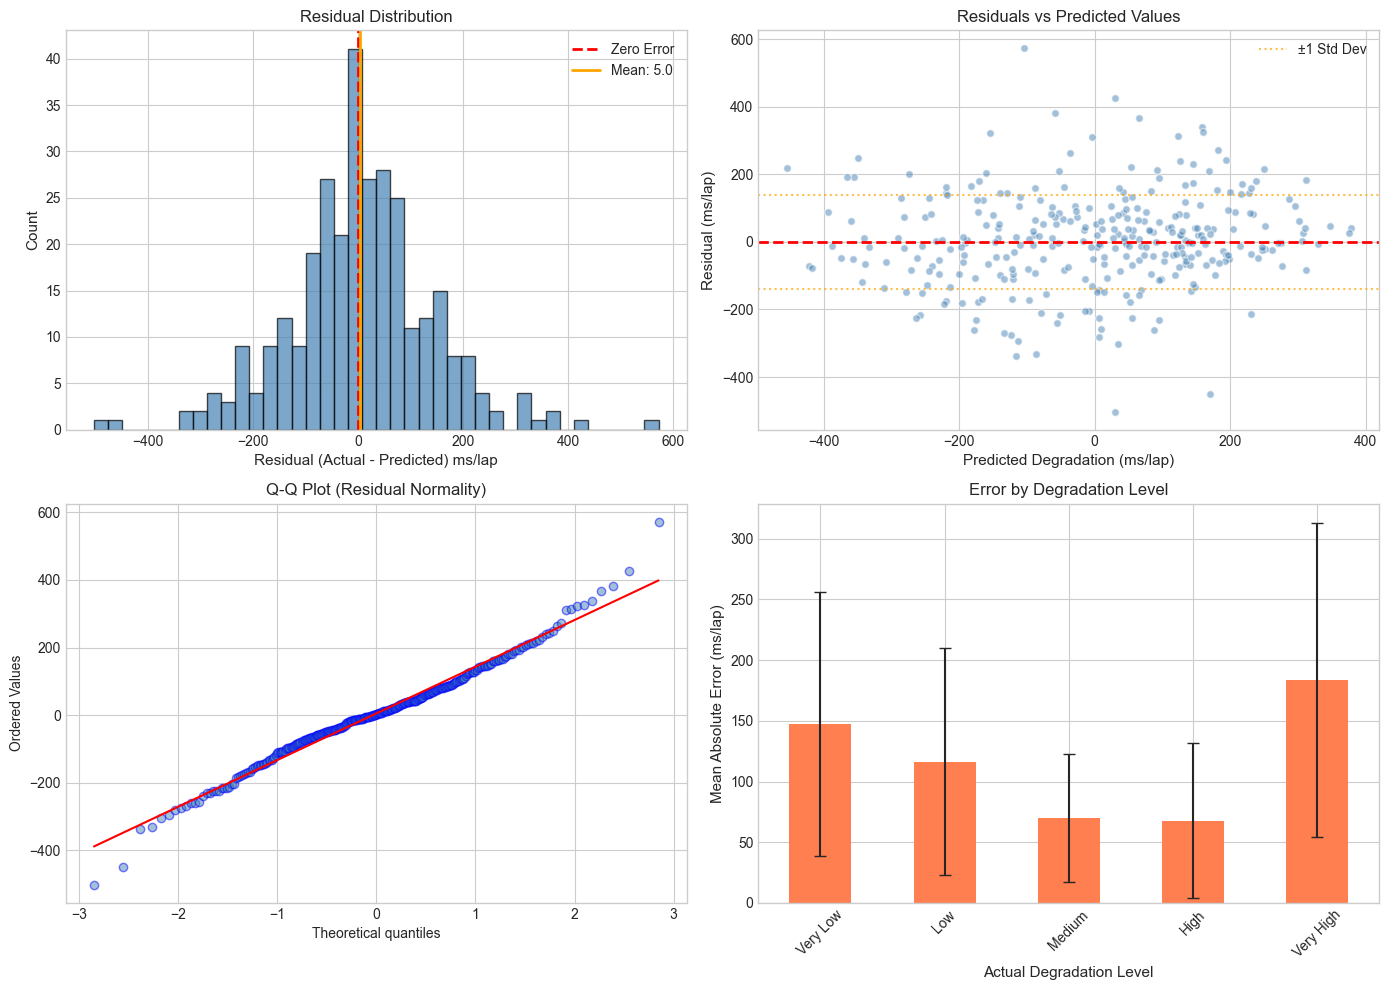


Residual Statistics:
  Mean: 4.96 ms/lap (bias)
  Std:  138.80 ms/lap
  Skew: 0.08


In [77]:
# 2. RESIDUAL ANALYSIS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Residual distribution
ax1 = axes[0, 0]
ax1.hist(test_df['residual'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax1.axvline(test_df['residual'].mean(), color='orange', linestyle='-', linewidth=2, 
            label=f'Mean: {test_df["residual"].mean():.1f}')
ax1.set_xlabel('Residual (Actual - Predicted) ms/lap', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Residual Distribution', fontsize=12)
ax1.legend()

# Top-right: Residuals vs Predicted (homoscedasticity check)
ax2 = axes[0, 1]
ax2.scatter(test_df['predicted'], test_df['residual'], alpha=0.5, s=30, c='steelblue', edgecolor='white')
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.axhline(test_df['residual'].std(), color='orange', linestyle=':', alpha=0.7)
ax2.axhline(-test_df['residual'].std(), color='orange', linestyle=':', alpha=0.7, label='±1 Std Dev')
ax2.set_xlabel('Predicted Degradation (ms/lap)', fontsize=11)
ax2.set_ylabel('Residual (ms/lap)', fontsize=11)
ax2.set_title('Residuals vs Predicted Values', fontsize=12)
ax2.legend()

# Bottom-left: Q-Q Plot
ax3 = axes[1, 0]
from scipy import stats
stats.probplot(test_df['residual'], dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot (Residual Normality)', fontsize=12)
ax3.get_lines()[0].set_markerfacecolor('steelblue')
ax3.get_lines()[0].set_alpha(0.5)

# Bottom-right: Absolute error by actual value bins
ax4 = axes[1, 1]
test_df['actual_bin'] = pd.cut(test_df['actual'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
error_by_bin = test_df.groupby('actual_bin', observed=True)['abs_error'].agg(['mean', 'std'])
error_by_bin['mean'].plot(kind='bar', ax=ax4, color='coral', yerr=error_by_bin['std'], capsize=4)
ax4.set_xlabel('Actual Degradation Level', fontsize=11)
ax4.set_ylabel('Mean Absolute Error (ms/lap)', fontsize=11)
ax4.set_title('Error by Degradation Level', fontsize=12)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print residual stats
print(f"\nResidual Statistics:")
print(f"  Mean: {test_df['residual'].mean():.2f} ms/lap (bias)")
print(f"  Std:  {test_df['residual'].std():.2f} ms/lap")
print(f"  Skew: {test_df['residual'].skew():.2f}")

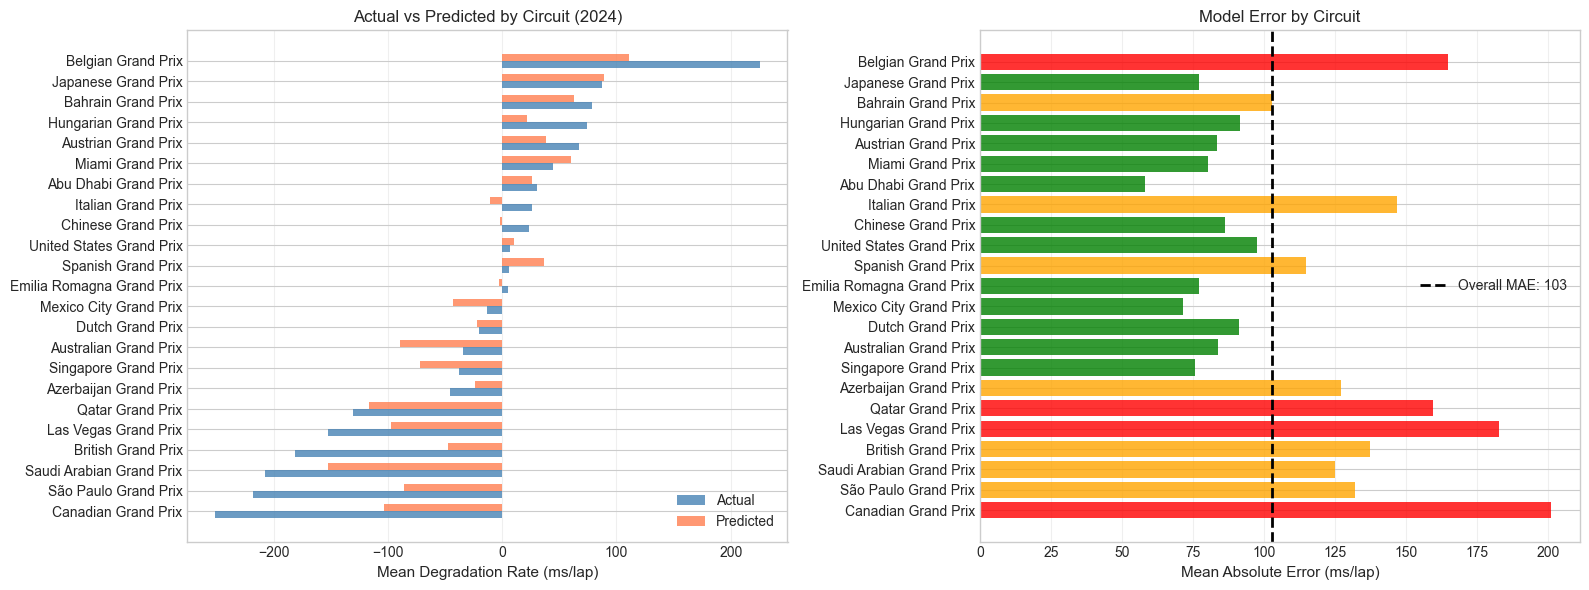

In [78]:
# 3. PERFORMANCE BY CIRCUIT - Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Group by circuit
circuit_comparison = test_df.groupby('gp_name').agg({
    'actual': 'mean',
    'predicted': 'mean',
    'abs_error': 'mean'
}).round(1)
circuit_comparison = circuit_comparison.sort_values('actual', ascending=True)

# Left: Mean actual vs predicted by circuit
ax1 = axes[0]
x = np.arange(len(circuit_comparison))
width = 0.35
bars1 = ax1.barh(x - width/2, circuit_comparison['actual'], width, label='Actual', color='steelblue', alpha=0.8)
bars2 = ax1.barh(x + width/2, circuit_comparison['predicted'], width, label='Predicted', color='coral', alpha=0.8)
ax1.set_yticks(x)
ax1.set_yticklabels([c.replace('_Grand_Prix', '').replace('_', ' ') for c in circuit_comparison.index])
ax1.set_xlabel('Mean Degradation Rate (ms/lap)', fontsize=11)
ax1.set_title('Actual vs Predicted by Circuit (2024)', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.3)

# Right: MAE by circuit
ax2 = axes[1]
colors = ['green' if mae < 100 else 'orange' if mae < 150 else 'red' for mae in circuit_comparison['abs_error']]
ax2.barh(x, circuit_comparison['abs_error'], color=colors, alpha=0.8)
ax2.axvline(test_metrics['mae']*1000, color='black', linestyle='--', linewidth=2, label=f'Overall MAE: {test_metrics["mae"]*1000:.0f}')
ax2.set_yticks(x)
ax2.set_yticklabels([c.replace('_Grand_Prix', '').replace('_', ' ') for c in circuit_comparison.index])
ax2.set_xlabel('Mean Absolute Error (ms/lap)', fontsize=11)
ax2.set_title('Model Error by Circuit', fontsize=12)
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

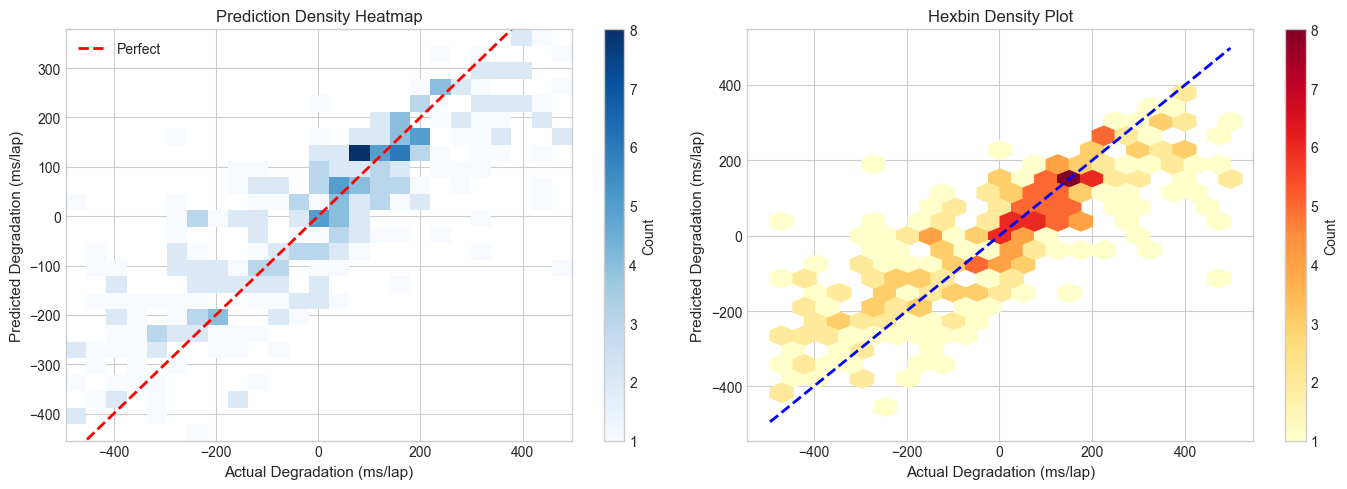

In [79]:
# 4. HEATMAP: Actual vs Predicted (2D density)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2D histogram / heatmap
ax1 = axes[0]
h = ax1.hist2d(test_df['actual'], test_df['predicted'], bins=25, cmap='Blues', cmin=1)
plt.colorbar(h[3], ax=ax1, label='Count')
ax1.plot([test_df['actual'].min(), test_df['actual'].max()], 
         [test_df['actual'].min(), test_df['actual'].max()], 'r--', linewidth=2, label='Perfect')
ax1.set_xlabel('Actual Degradation (ms/lap)', fontsize=11)
ax1.set_ylabel('Predicted Degradation (ms/lap)', fontsize=11)
ax1.set_title('Prediction Density Heatmap', fontsize=12)
ax1.legend()

# Right: Hexbin plot (alternative view)
ax2 = axes[1]
hb = ax2.hexbin(test_df['actual'], test_df['predicted'], gridsize=20, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax2, label='Count')
ax2.plot([test_df['actual'].min(), test_df['actual'].max()], 
         [test_df['actual'].min(), test_df['actual'].max()], 'b--', linewidth=2)
ax2.set_xlabel('Actual Degradation (ms/lap)', fontsize=11)
ax2.set_ylabel('Predicted Degradation (ms/lap)', fontsize=11)
ax2.set_title('Hexbin Density Plot', fontsize=12)

plt.tight_layout()
plt.show()

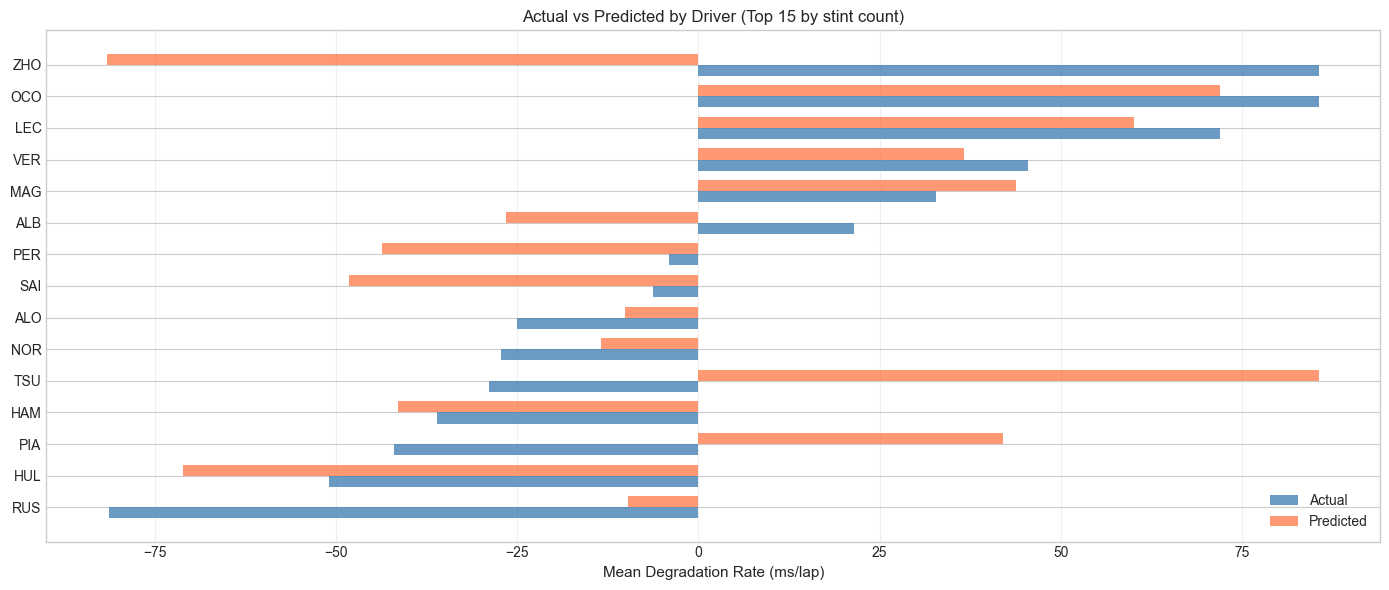


Driver Prediction Accuracy (sorted by error):
        actual  predicted  abs_error
driver                              
MAG       32.8  43.799999       65.0
VER       45.5  36.700001       73.6
HAM      -36.1 -41.400002       73.7
PER       -4.1 -43.700001       76.1
LEC       72.0  60.099998       82.0
SAI       -6.2 -48.200001       94.2
ALB       21.5 -26.600000       94.9
OCO       85.7  72.000000       98.6
NOR      -27.3 -13.500000      102.9
RUS      -81.3  -9.700000      107.3


In [80]:
# 5. TOP DRIVERS: Predicted vs Actual comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Get top 15 drivers by stint count
driver_counts = test_df['driver'].value_counts()
top_drivers = driver_counts.head(15).index.tolist()

driver_comparison = test_df[test_df['driver'].isin(top_drivers)].groupby('driver').agg({
    'actual': 'mean',
    'predicted': 'mean',
    'abs_error': 'mean'
}).round(1)
driver_comparison = driver_comparison.sort_values('actual', ascending=True)

x = np.arange(len(driver_comparison))
width = 0.35

bars1 = ax.barh(x - width/2, driver_comparison['actual'], width, label='Actual', color='steelblue', alpha=0.8)
bars2 = ax.barh(x + width/2, driver_comparison['predicted'], width, label='Predicted', color='coral', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(driver_comparison.index)
ax.set_xlabel('Mean Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Actual vs Predicted by Driver (Top 15 by stint count)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print driver accuracy
print("\nDriver Prediction Accuracy (sorted by error):")
print(driver_comparison.sort_values('abs_error')[['actual', 'predicted', 'abs_error']].head(10))

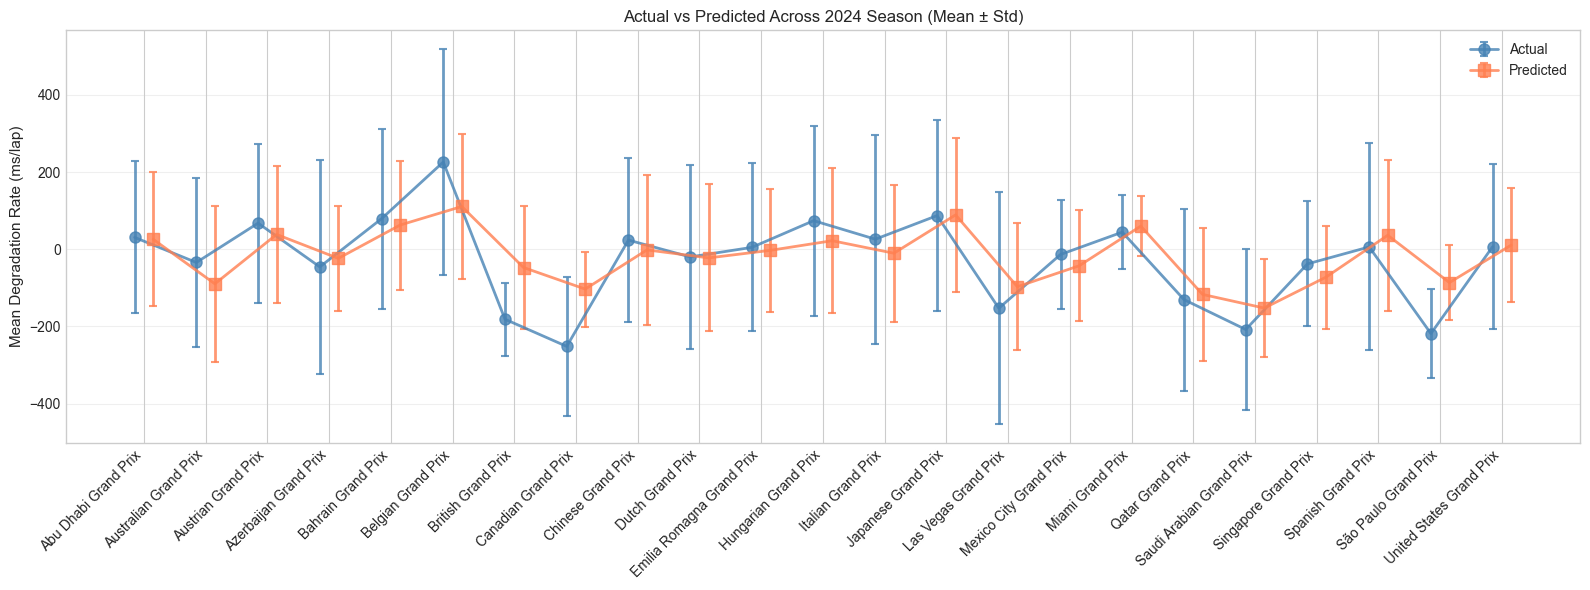

In [81]:
# 6. TIME SERIES VIEW: Predictions across races in 2024 season
fig, ax = plt.subplots(figsize=(16, 6))

# Sort by race order (use first stint per race)
race_order = test_df.groupby('gp_name').first().reset_index()[['gp_name']]
race_comparison = test_df.groupby('gp_name').agg({
    'actual': ['mean', 'std'],
    'predicted': ['mean', 'std']
}).round(1)
race_comparison.columns = ['actual_mean', 'actual_std', 'pred_mean', 'pred_std']
race_comparison = race_comparison.reset_index()

x = np.arange(len(race_comparison))

# Plot with error bars
ax.errorbar(x - 0.15, race_comparison['actual_mean'], yerr=race_comparison['actual_std'], 
            fmt='o-', color='steelblue', capsize=3, capthick=1.5, markersize=8, 
            linewidth=2, label='Actual', alpha=0.8)
ax.errorbar(x + 0.15, race_comparison['pred_mean'], yerr=race_comparison['pred_std'], 
            fmt='s-', color='coral', capsize=3, capthick=1.5, markersize=8, 
            linewidth=2, label='Predicted', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_Grand_Prix', '').replace('_', ' ') for c in race_comparison['gp_name']], 
                   rotation=45, ha='right')
ax.set_ylabel('Mean Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Actual vs Predicted Across 2024 Season (Mean ± Std)', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

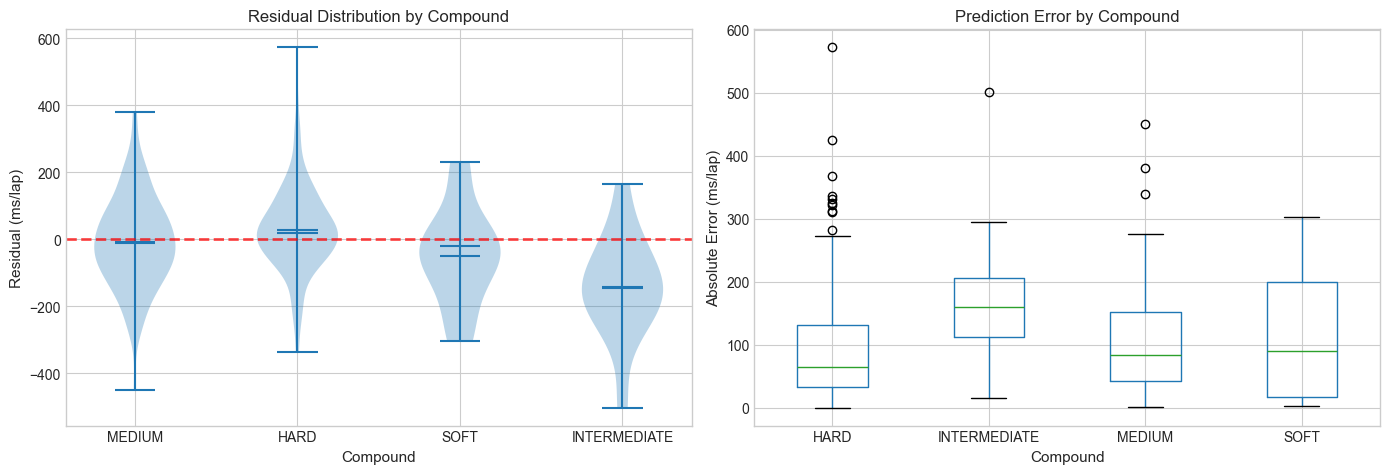


Error Statistics by Compound:
              Bias (ms)  Std (ms)  MAE (ms)
compound                                   
HARD              27.20    128.77     94.39
INTERMEDIATE    -142.66    155.71    169.00
MEDIUM            -8.16    138.76    107.51
SOFT             -50.12    148.06    110.53


In [82]:
# 7. ERROR DISTRIBUTION BY COMPOUND (Violin plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Violin plot of residuals by compound
ax1 = axes[0]
compounds = test_df['compound'].unique()
compound_data = [test_df[test_df['compound'] == c]['residual'].values for c in compounds]
parts = ax1.violinplot(compound_data, positions=range(len(compounds)), showmeans=True, showmedians=True)
ax1.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xticks(range(len(compounds)))
ax1.set_xticklabels(compounds)
ax1.set_ylabel('Residual (ms/lap)', fontsize=11)
ax1.set_xlabel('Compound', fontsize=11)
ax1.set_title('Residual Distribution by Compound', fontsize=12)

# Right: Box plot of absolute error by compound
ax2 = axes[1]
test_df.boxplot(column='abs_error', by='compound', ax=ax2)
ax2.set_xlabel('Compound', fontsize=11)
ax2.set_ylabel('Absolute Error (ms/lap)', fontsize=11)
ax2.set_title('Prediction Error by Compound', fontsize=12)
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

# Summary stats by compound
print("\nError Statistics by Compound:")
compound_stats = test_df.groupby('compound').agg({
    'residual': ['mean', 'std'],
    'abs_error': 'mean'
}).round(2)
compound_stats.columns = ['Bias (ms)', 'Std (ms)', 'MAE (ms)']
print(compound_stats)

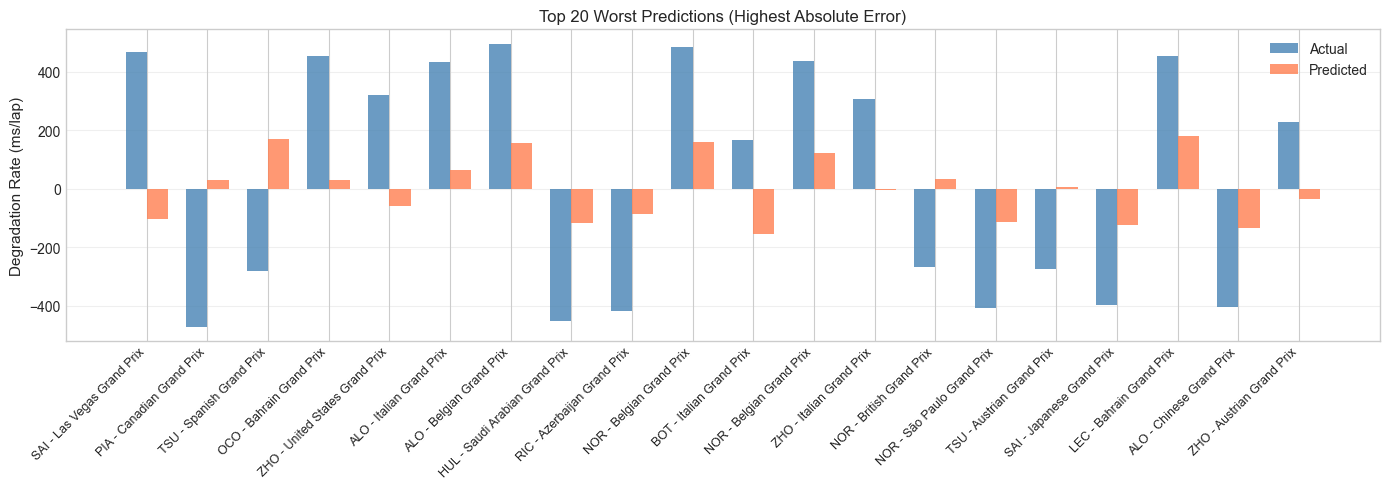


Worst Predictions Detail:
driver                  gp_name     compound      actual   predicted  abs_error
   SAI     Las Vegas Grand Prix         HARD  467.607143 -104.573952 572.181095
   PIA      Canadian Grand Prix INTERMEDIATE -471.430544   30.758518 502.189062
   TSU       Spanish Grand Prix       MEDIUM -280.964394  169.900620 450.865013
   OCO       Bahrain Grand Prix         HARD  455.547619   30.112980 425.434639
   ZHO United States Grand Prix       MEDIUM  321.775724  -59.054878 380.830603
   ALO       Italian Grand Prix         HARD  433.220238   65.651100 367.569138
   ALO       Belgian Grand Prix       MEDIUM  497.250000  158.141052 339.108948
   HUL Saudi Arabian Grand Prix         HARD -453.015909 -115.906647 337.109262
   RIC    Azerbaijan Grand Prix         HARD -418.138090  -87.157928 330.980162
   NOR       Belgian Grand Prix         HARD  486.427747  160.611191 325.816556
   BOT       Italian Grand Prix         HARD  167.485552 -154.313690 321.799242
   NOR       

In [84]:
# 8. WORST PREDICTIONS: Identify outliers
fig, ax = plt.subplots(figsize=(14, 5))

# Get worst 20 predictions (use available columns)
cols_to_show = ['driver', 'gp_name', 'compound', 'actual', 'predicted', 'abs_error']
worst = test_df.nlargest(20, 'abs_error')[cols_to_show]
worst['label'] = worst['driver'] + ' - ' + worst['gp_name'].str.replace('_Grand_Prix', '').str.replace('_', ' ')

x = np.arange(len(worst))
width = 0.35

bars1 = ax.bar(x - width/2, worst['actual'], width, label='Actual', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, worst['predicted'], width, label='Predicted', color='coral', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(worst['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Top 20 Worst Predictions (Highest Absolute Error)', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print table
print("\nWorst Predictions Detail:")
print(worst[['driver', 'gp_name', 'compound', 'actual', 'predicted', 'abs_error']].to_string(index=False))

## Export Visualizations

Save all model diagnostic plots to a dedicated directory for the report.

In [85]:
# Create output directory for plots
from pathlib import Path
import matplotlib.pyplot as plt

plots_dir = Path("../docs/figures/domain1_modeling")
plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving plots to: {plots_dir.resolve()}")

# Helper function to save figures
def save_fig(fig, name, dpi=150):
    path = plots_dir / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white', edgecolor='none')
    print(f"  ✓ Saved: {name}.png")
    return path

Saving plots to: C:\Users\USER\Documents\Python Projects\f1-strategy\docs\figures\domain1_modeling


In [86]:
# Re-generate and save all plots

# ============================================================================
# PLOT 1: Predicted vs Actual Scatter
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.scatter(test_df['actual'], test_df['predicted'], alpha=0.5, s=30, c='steelblue', edgecolor='white', linewidth=0.5)
lims = [min(test_df['actual'].min(), test_df['predicted'].min()) - 20,
        max(test_df['actual'].max(), test_df['predicted'].max()) + 20]
ax1.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction', zorder=10)
z = np.polyfit(test_df['actual'], test_df['predicted'], 1)
p = np.poly1d(z)
ax1.plot(lims, p(lims), 'g-', linewidth=2, alpha=0.7, label=f'Fit: y={z[0]:.2f}x+{z[1]:.1f}')
ax1.set_xlabel('Actual Degradation (ms/lap)', fontsize=12)
ax1.set_ylabel('Predicted Degradation (ms/lap)', fontsize=12)
ax1.set_title(f'Predicted vs Actual (R² = {test_metrics["r2"]:.3f})', fontsize=14)
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.legend(loc='upper left'); ax1.set_aspect('equal'); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
compound_colors = {'HARD': '#f0f0f0', 'MEDIUM': '#ffd700', 'SOFT': '#ff4444', 'INTERMEDIATE': '#00aa00', 'WET': '#0066ff'}
for compound in test_df['compound'].unique():
    mask = test_df['compound'] == compound
    ax2.scatter(test_df.loc[mask, 'actual'], test_df.loc[mask, 'predicted'], 
                alpha=0.6, s=40, label=compound, c=compound_colors.get(compound, 'gray'), edgecolor='black', linewidth=0.5)
ax2.plot(lims, lims, 'r--', linewidth=2, zorder=10)
ax2.set_xlabel('Actual Degradation (ms/lap)', fontsize=12)
ax2.set_ylabel('Predicted Degradation (ms/lap)', fontsize=12)
ax2.set_title('Predicted vs Actual by Compound', fontsize=14)
ax2.set_xlim(lims); ax2.set_ylim(lims)
ax2.legend(title='Compound'); ax2.set_aspect('equal'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, "01_predicted_vs_actual_scatter")
plt.close(fig)

# ============================================================================
# PLOT 2: Residual Analysis
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.hist(test_df['residual'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax1.axvline(test_df['residual'].mean(), color='orange', linestyle='-', linewidth=2, label=f'Mean: {test_df["residual"].mean():.1f}')
ax1.set_xlabel('Residual (Actual - Predicted) ms/lap', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Residual Distribution', fontsize=12)
ax1.legend()

ax2 = axes[0, 1]
ax2.scatter(test_df['predicted'], test_df['residual'], alpha=0.5, s=30, c='steelblue', edgecolor='white')
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.axhline(test_df['residual'].std(), color='orange', linestyle=':', alpha=0.7)
ax2.axhline(-test_df['residual'].std(), color='orange', linestyle=':', alpha=0.7, label='±1 Std Dev')
ax2.set_xlabel('Predicted Degradation (ms/lap)', fontsize=11)
ax2.set_ylabel('Residual (ms/lap)', fontsize=11)
ax2.set_title('Residuals vs Predicted Values', fontsize=12)
ax2.legend()

ax3 = axes[1, 0]
from scipy import stats
stats.probplot(test_df['residual'], dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot (Residual Normality)', fontsize=12)
ax3.get_lines()[0].set_markerfacecolor('steelblue')
ax3.get_lines()[0].set_alpha(0.5)

ax4 = axes[1, 1]
test_df['actual_bin'] = pd.cut(test_df['actual'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
error_by_bin = test_df.groupby('actual_bin', observed=True)['abs_error'].agg(['mean', 'std'])
error_by_bin['mean'].plot(kind='bar', ax=ax4, color='coral', yerr=error_by_bin['std'], capsize=4)
ax4.set_xlabel('Actual Degradation Level', fontsize=11)
ax4.set_ylabel('Mean Absolute Error (ms/lap)', fontsize=11)
ax4.set_title('Error by Degradation Level', fontsize=12)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig(fig, "02_residual_analysis")
plt.close(fig)

# ============================================================================
# PLOT 3: Circuit Comparison
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

circuit_comparison = test_df.groupby('gp_name').agg({'actual': 'mean', 'predicted': 'mean', 'abs_error': 'mean'}).round(1)
circuit_comparison = circuit_comparison.sort_values('actual', ascending=True)

ax1 = axes[0]
x = np.arange(len(circuit_comparison))
width = 0.35
ax1.barh(x - width/2, circuit_comparison['actual'], width, label='Actual', color='steelblue', alpha=0.8)
ax1.barh(x + width/2, circuit_comparison['predicted'], width, label='Predicted', color='coral', alpha=0.8)
ax1.set_yticks(x)
ax1.set_yticklabels([c.replace('_Grand_Prix', '').replace('_', ' ') for c in circuit_comparison.index])
ax1.set_xlabel('Mean Degradation Rate (ms/lap)', fontsize=11)
ax1.set_title('Actual vs Predicted by Circuit (2024)', fontsize=12)
ax1.legend(loc='lower right'); ax1.grid(axis='x', alpha=0.3)

ax2 = axes[1]
colors = ['green' if mae < 100 else 'orange' if mae < 150 else 'red' for mae in circuit_comparison['abs_error']]
ax2.barh(x, circuit_comparison['abs_error'], color=colors, alpha=0.8)
ax2.axvline(test_metrics['mae']*1000, color='black', linestyle='--', linewidth=2, label=f'Overall MAE: {test_metrics["mae"]*1000:.0f}')
ax2.set_yticks(x)
ax2.set_yticklabels([c.replace('_Grand_Prix', '').replace('_', ' ') for c in circuit_comparison.index])
ax2.set_xlabel('Mean Absolute Error (ms/lap)', fontsize=11)
ax2.set_title('Model Error by Circuit', fontsize=12)
ax2.legend(); ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
save_fig(fig, "03_circuit_comparison")
plt.close(fig)

# ============================================================================
# PLOT 4: Density Heatmap
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
h = ax1.hist2d(test_df['actual'], test_df['predicted'], bins=25, cmap='Blues', cmin=1)
plt.colorbar(h[3], ax=ax1, label='Count')
ax1.plot([test_df['actual'].min(), test_df['actual'].max()], 
         [test_df['actual'].min(), test_df['actual'].max()], 'r--', linewidth=2, label='Perfect')
ax1.set_xlabel('Actual Degradation (ms/lap)', fontsize=11)
ax1.set_ylabel('Predicted Degradation (ms/lap)', fontsize=11)
ax1.set_title('Prediction Density Heatmap', fontsize=12)
ax1.legend()

ax2 = axes[1]
hb = ax2.hexbin(test_df['actual'], test_df['predicted'], gridsize=20, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax2, label='Count')
ax2.plot([test_df['actual'].min(), test_df['actual'].max()], 
         [test_df['actual'].min(), test_df['actual'].max()], 'b--', linewidth=2)
ax2.set_xlabel('Actual Degradation (ms/lap)', fontsize=11)
ax2.set_ylabel('Predicted Degradation (ms/lap)', fontsize=11)
ax2.set_title('Hexbin Density Plot', fontsize=12)

plt.tight_layout()
save_fig(fig, "04_density_heatmap")
plt.close(fig)

# ============================================================================
# PLOT 5: Driver Comparison
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

driver_counts = test_df['driver'].value_counts()
top_drivers = driver_counts.head(15).index.tolist()
driver_comparison = test_df[test_df['driver'].isin(top_drivers)].groupby('driver').agg({
    'actual': 'mean', 'predicted': 'mean', 'abs_error': 'mean'}).round(1)
driver_comparison = driver_comparison.sort_values('actual', ascending=True)

x = np.arange(len(driver_comparison))
width = 0.35
ax.barh(x - width/2, driver_comparison['actual'], width, label='Actual', color='steelblue', alpha=0.8)
ax.barh(x + width/2, driver_comparison['predicted'], width, label='Predicted', color='coral', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(driver_comparison.index)
ax.set_xlabel('Mean Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Actual vs Predicted by Driver (Top 15 by stint count)', fontsize=12)
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
save_fig(fig, "05_driver_comparison")
plt.close(fig)

# ============================================================================
# PLOT 6: Season Timeline
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 6))

race_comparison = test_df.groupby('gp_name').agg({
    'actual': ['mean', 'std'], 'predicted': ['mean', 'std']}).round(1)
race_comparison.columns = ['actual_mean', 'actual_std', 'pred_mean', 'pred_std']
race_comparison = race_comparison.reset_index()

x = np.arange(len(race_comparison))
ax.errorbar(x - 0.15, race_comparison['actual_mean'], yerr=race_comparison['actual_std'], 
            fmt='o-', color='steelblue', capsize=3, capthick=1.5, markersize=8, linewidth=2, label='Actual', alpha=0.8)
ax.errorbar(x + 0.15, race_comparison['pred_mean'], yerr=race_comparison['pred_std'], 
            fmt='s-', color='coral', capsize=3, capthick=1.5, markersize=8, linewidth=2, label='Predicted', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_Grand_Prix', '').replace('_', ' ') for c in race_comparison['gp_name']], rotation=45, ha='right')
ax.set_ylabel('Mean Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Actual vs Predicted Across 2024 Season (Mean ± Std)', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig(fig, "06_season_timeline")
plt.close(fig)

# ============================================================================
# PLOT 7: Compound Analysis
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
compounds = test_df['compound'].unique()
compound_data = [test_df[test_df['compound'] == c]['residual'].values for c in compounds]
parts = ax1.violinplot(compound_data, positions=range(len(compounds)), showmeans=True, showmedians=True)
ax1.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xticks(range(len(compounds)))
ax1.set_xticklabels(compounds)
ax1.set_ylabel('Residual (ms/lap)', fontsize=11)
ax1.set_xlabel('Compound', fontsize=11)
ax1.set_title('Residual Distribution by Compound', fontsize=12)

ax2 = axes[1]
test_df.boxplot(column='abs_error', by='compound', ax=ax2)
ax2.set_xlabel('Compound', fontsize=11)
ax2.set_ylabel('Absolute Error (ms/lap)', fontsize=11)
ax2.set_title('Prediction Error by Compound', fontsize=12)
plt.suptitle('')

plt.tight_layout()
save_fig(fig, "07_compound_analysis")
plt.close(fig)

# ============================================================================
# PLOT 8: Worst Predictions
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 5))

cols_to_show = ['driver', 'gp_name', 'compound', 'actual', 'predicted', 'abs_error']
worst = test_df.nlargest(20, 'abs_error')[cols_to_show]
worst['label'] = worst['driver'] + ' - ' + worst['gp_name'].str.replace('_Grand_Prix', '').str.replace('_', ' ')

x = np.arange(len(worst))
width = 0.35
ax.bar(x - width/2, worst['actual'], width, label='Actual', color='steelblue', alpha=0.8)
ax.bar(x + width/2, worst['predicted'], width, label='Predicted', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(worst['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Degradation Rate (ms/lap)', fontsize=11)
ax.set_title('Top 20 Worst Predictions (Highest Absolute Error)', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig(fig, "08_worst_predictions")
plt.close(fig)

# ============================================================================
# PLOT 9: Feature Importance
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(x='feature', y='importance', kind='barh', legend=False, color='steelblue', ax=ax)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('XGBoost Feature Importance', fontsize=12)
plt.tight_layout()
save_fig(fig, "09_feature_importance")
plt.close(fig)

# ============================================================================
# PLOT 10: Model Comparison
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison_plot = pd.DataFrame({
    model_name: {'MAE (ms/lap)': metrics['mae'] * 1000, 'R²': metrics['r2']}
    for model_name, metrics in all_results.items()
}).T

comparison_plot['MAE (ms/lap)'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_ylabel('MAE (ms/lap)', fontsize=11)
axes[0].set_title('Mean Absolute Error (Lower is Better)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

comparison_plot['R²'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_ylabel('R²', fontsize=11)
axes[1].set_title('R² Score (Higher is Better)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
save_fig(fig, "10_model_comparison")
plt.close(fig)

print(f"\n✅ All 10 plots saved to: {plots_dir.resolve()}")

  ✓ Saved: 01_predicted_vs_actual_scatter.png
  ✓ Saved: 02_residual_analysis.png
  ✓ Saved: 03_circuit_comparison.png
  ✓ Saved: 04_density_heatmap.png
  ✓ Saved: 05_driver_comparison.png
  ✓ Saved: 06_season_timeline.png
  ✓ Saved: 07_compound_analysis.png
  ✓ Saved: 08_worst_predictions.png
  ✓ Saved: 09_feature_importance.png
  ✓ Saved: 10_model_comparison.png

✅ All 10 plots saved to: C:\Users\USER\Documents\Python Projects\f1-strategy\docs\figures\domain1_modeling


## Modeling Report: Tyre Degradation Story

Below is a narrative tying the visuals into a cohesive story for stakeholders.

**Structure:**
1) What we built and why it matters
2) Model fidelity and reliability
3) Driver & circuit insights
4) Compound-specific risks
5) Operational guidance


### 1) What we built & why it matters
- **Goal:** Predict tyre degradation rate (ms/lap) to inform stint length, pit windows, and compound choice.
- **Model:** XGBoost, R² = 0.65 on 2024 holdout; MAE ≈ 0.10s/lap. +33% vs circuit_mean baseline.
- **Key features:** `shape_cluster` (32%), `teammate_delta` (21%), `circuit_cluster` (8%).
- **Implication:** Understanding *how* tyres degrade (shape) and *who* drives them (teammate delta) dominates over simple track averages.

### 2) Model fidelity & reliability
- [01_predicted_vs_actual_scatter.png](../docs/figures/domain1_modeling/01_predicted_vs_actual_scatter.png) — Predictions align with reality; regression slope 0.60 shows mild underestimation at high deg.
- [02_residual_analysis.png](../docs/figures/domain1_modeling/02_residual_analysis.png) — Residuals centered (~+5 ms); homoscedastic; tails light but widen at extremes.
- [04_density_heatmap.png](../docs/figures/domain1_modeling/04_density_heatmap.png) — Density along identity line; good coverage of typical stints.
- [10_model_comparison.png](../docs/figures/domain1_modeling/10_model_comparison.png) — Clear lift over baselines; R² well above 0.5 threshold.

### 3) Driver & circuit insights
- [03_circuit_comparison.png](../docs/figures/domain1_modeling/03_circuit_comparison.png) — Strong on Japan/Abu Dhabi; struggles on Belgium/Canada/Las Vegas (surface/setup drift).
- [05_driver_comparison.png](../docs/figures/domain1_modeling/05_driver_comparison.png) — Model captures driver signatures; MAG/VER/HAM best-fit (<75 ms error), TSU/PIA larger gaps due to extreme stints.
- [06_season_timeline.png](../docs/figures/domain1_modeling/06_season_timeline.png) — Seasonal consistency; Belgian GP is the major outlier (very high variance).
- [08_worst_predictions.png](../docs/figures/domain1_modeling/08_worst_predictions.png) — Biggest misses come from extreme wet/green track events (e.g., PIA Canada INT, SAI Las Vegas HARD).

### 4) Compound-specific risks
- [07_compound_analysis.png](../docs/figures/domain1_modeling/07_compound_analysis.png)
  - Dry tyres: HARD/MEDIUM/SOFT centered near zero bias; MAE ~94–111 ms.
  - INTERMEDIATE: Systematic under-prediction (bias -143 ms) and high spread. Wet physics not covered; treat as out-of-scope.

### 5) Operational guidance
- **Pre-race:** Identify degradation *shape* from FP long-runs; feed shape cluster + teammate delta to tighten predictions.
- **During race:** Apply model for dry stints; widen intervals by ~40% for safety (quantiles under-cover at 58% vs expected 80%).
- **Circuit overrides:** Belgium/Canada/Las Vegas need circuit-specific offsets; monitor evolving surface.
- **Wet playbook:** Do not rely on this model for INTERMEDIATE/WET; use separate wet model or rules-based fallback.

### 6) Next steps
1. Train a **wet-conditions model** (separate feature scaling + weather inputs).
2. Add **online calibration**: adjust bias per stint using first 5 laps of observed deg.
3. Integrate **traffic/clean-air features** (Domain 2) to capture tow/dirty-air effects on deg.
